## Predicting March Madness Qualifiers Using a Random Forest

Bracketologists spend hours combing through metrics to determine which teams will qualify for NCAA Basketball's iconic postseason, March Madness. The selection committee uses known metrics, so I figured there's no reason you couldn't build a model to digest all these metrics and spit out a prediction if that team will make the tournament. The following notebook describes data acquisition, data evaluation, and a few drawbacks/opportunities for future work.

### Setup

Importing packages... shoutout to [kenpompy](https://kenpompy.readthedocs.io/en/latest/) for making kenpom webscraping pretty simple (although we end up not using most kenpom data, more on that later). Other than that, `pandas`/`numpy` for data manipulation, `maplotlib` for viz, `BeautifulSoup` for webscraping, and `sklearn` for model training.

In [ ]:
import pandas as pd
from kenpompy.utils import login
import kenpompy.summary as kp
import kenpompy.team as kt
from kenpompy.misc import *
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

Browser for kenpom webscraping - recquires a premium subscription

In [ ]:
browser = login(login, password)

### Data Acquistion

Here I create the initial dataframe using kenpom data. Later, you'll see the model doesn't really use kenpom data. I initially thought I would use a good amount of efficiency metrics from kenpom. This did result in a pretty good model, but it doesn't really mirror what the committee is doing. The committee is concerned with _resume_ while kenpom is concerned with _efficiency_. The two are highly correlated, but it's completely possible for a team who has a strong kenpom rating to have tripped up enough in the regular season and miss the tournament. The reverse is also true. 

Also, I initially thought a non null value in the `seed` column would represent a team that made the tournament, but it turns out there were randomly some NIT teams with a `seed`. Instead of combing through those and filtering, I used another source for that as well.

We still get some use from kenpom data. The committee does care about strength of schedule, so we'll keep that around in the final model.

Lastly, I chose to train the model on data since 2019, since that is when the selection committee started using the NET rankings and the Quad system. I could write an entire post about the flaws with the Quad system, but that is what the committee uses, so I digress.

In [9]:
kenpom_ratings = []

## loop through kenpom data 
for year in range(2019, 2025):
    ratings = get_pomeroy_ratings(browser, year)
    ratings['year'] = year
    kenpom_ratings.append(ratings) 

kenpom_ratings = pd.concat(kenpom_ratings, ignore_index=True)

## remove 2020, no tournament
kenpom_ratings = kenpom_ratings[kenpom_ratings['year'] != 2020]

## select columns of interest
kenpom_ratings = kenpom_ratings[['Team', 'year', 'Seed', 'Conf', 'W-L', 'SOS-AdjEM.Rank', 'AdjEM', 'AdjO.Rank', 'AdjD.Rank']]

## rename columns
kenpom_ratings.columns = ['team', 'year', 'seed', 'conference', 'record', 'sos_adj_em_rank', 'adj_em', 'o_adj_rank', 'd_adj_rank']

## convert wins and losses to percentage
kenpom_ratings[['wins', 'losses']] = kenpom_ratings['record'].str.split('-', expand=True).astype(int)

## remove teams who didn't play a 2021 season
kenpom_ratings = kenpom_ratings[kenpom_ratings['wins'] + kenpom_ratings['losses'] > 0]

## drop wins and losses, kenpom tracks from after tournament
kenpom_ratings = kenpom_ratings.drop(['wins', 'losses'], axis = 1)

## remove '+' from adjusted efficiency, convert to double
kenpom_ratings['adj_em'] = kenpom_ratings['adj_em'].str.replace('+', '', regex=False).astype('double')

## create rank column for efficiency
kenpom_ratings['adj_em_rank'] = kenpom_ratings.groupby('year')['adj_em'].rank(ascending=False, method='min').astype(int)

kenpom_ratings.head()

,team,year,seed,conference,record,sos_adj_em_rank,adj_em,o_adj_rank,d_adj_rank,adj_em_rank
0,Virginia,2019,1,ACC,35-3,22,34.22,2,5,1
1,Gonzaga,2019,1,WCC,33-4,75,32.85,1,12,2
2,Michigan St.,2019,2,B10,32-7,2,30.81,5,9,3
3,Duke,2019,1,ACC,32-6,7,30.62,7,6,4
4,Texas Tech,2019,3,B12,31-7,21,30.03,25,1,5


Here I scrape [https://www.sports-reference.com](sports-reference.com) to grab conference tourney winners. Each conference tournament winner automatically qualifies for the NCAA tournament, so the model should learn this is a very important feature (spoiler, it does). Other than that, there are a couple data cleansing fixes here. Conference and team names are mapped to match kenpom data. Additionally, two teams that won their conference tournament but were inelidgible for the NCAA tournament were manually corrected. 

In [10]:
## loop through HTML from sports-reference.com to get automatic qualifiers since 2019

def scrape_automatic_qualifiers(year):
    year_data = []
    url = f"https://www.sports-reference.com/cbb/seasons/men/{year}.html#all_conference-summary"
    response = requests.get(url)
    html_content = response.text

    soup = BeautifulSoup(html_content, "html.parser")

    ## extract conference names
    conf_names = [tag.text.strip() for tag in soup.find_all("td", {"data-stat": "conf_name"})]

    ## extract automatic qualifiers
    conf_champs = [tag.text.strip() for tag in soup.find_all("td", {"data-stat": "conf_champ_post"})]
    
    for conf_name, conf_champ in zip(conf_names, conf_champs):
        year_data.append((year, conf_name, conf_champ))
        
    return(year_data)

conference_tourney_data = []

for year in range(2019, 2025):
    year_data = scrape_automatic_qualifiers(year)
    conference_tourney_data = [*conference_tourney_data, *year_data]

## create pandas df for automatic qualifiers
conference_tourney_winners = pd.DataFrame(conference_tourney_data, columns=['year', 'conference', 'postseason_champion'])

## remove independent, not an automatic qualifier
conference_tourney_winners = conference_tourney_winners[conference_tourney_winners['conference'] != 'Independent']

## remove 2020, no tournament
conference_tourney_winners = conference_tourney_winners[conference_tourney_winners['year'] != 2020]

## mapping dict to kenpom conference names
conference_mapping = {'Big 12 Conference': 'B12',
           'American Athletic Conference': 'Amer',
           'Southeastern Conference': 'SEC',
           'Big East Conference': 'BE',
           'Big Ten Conference': 'B10',
           'Pac-12 Conference': 'P12',
           'Atlantic 10 Conference': 'A10',
           'West Coast Conference': 'WCC',
           'Atlantic Coast Conference': 'ACC',
           'Mid-American Conference': 'MAC',
           'Colonial Athletic Association': 'CAA',
           'Ohio Valley Conference': 'OVC',
           'Conference USA': 'CUSA',
           'Missouri Valley Conference': 'MVC',
           'Ivy League': 'Ivy',
           'Southland Conference': 'Slnd',
           'Big South Conference': 'BSth',
           'Sun Belt Conference': 'SB',
           'Patriot League': 'PL',
           'Mountain West Conference': 'MWC',
           'Atlantic Sun Conference': 'ASun',
           'Western Athletic Conference': 'WAC',
           'Big Sky Conference': 'BSky',
           'Southern Conference': 'SC',
           'Horizon League': 'Horz',
           'Metro Atlantic Athletic Conference': 'MAAC',
           'America East Conference': 'AE',
           'Summit League': 'Sum',
           'Mid-Eastern Athletic Conference': 'MEAC',
           'Big West Conference': 'BW',
           'Northeast Conference': 'NEC',
           'Southwest Athletic Conference': 'SWAC',
           'Coastal Athletic Association': 'CAA'
           }

## map to kenpom names
conference_tourney_winners['conference'] = conference_tourney_winners['conference'].map(conference_mapping)

## mapping team names

## replace 'State' with 'St.'
conference_tourney_winners['postseason_champion'] = conference_tourney_winners['postseason_champion'].str.replace('State', 'St.')

## map remaining team names
conference_champs_team_name_mapping = {
    'College of Charleston': 'Charleston',
     'FDU': 'Fairleigh Dickinson',
     'Gardner-Webb': 'Gardner Webb',
     'Grambling': 'Grambling St.',
     'Loyola (IL)': 'Loyola Chicago',
     'NC St.': 'N.C. State',
     'Prairie View': 'Prairie View A&M',
     "Saint Mary's (CA)": "Saint Mary's",
     'Texas A&M-Corpus Christi': 'Texas A&M Corpus Chris',
     'Virginia Commonwealth': 'VCU'
}

conference_tourney_winners['postseason_champion'] = conference_tourney_winners['postseason_champion'].map(conference_champs_team_name_mapping).fillna(conference_tourney_winners['postseason_champion'])

## manually fix inelidgible conference winners

## Jax State get automatic bid because Bellermine inelidgible 
conference_tourney_winners.loc[(conference_tourney_winners['conference'] == 'ASun') & (conference_tourney_winners['year'] == 2022), 'postseason_champion'] = 'Jacksonville St.'

## Fairleigh Dickinson get automatic bid because Merrimack inelidgible 
conference_tourney_winners.loc[(conference_tourney_winners['conference'] == 'NEC') & (conference_tourney_winners['year'] == 2023), 'postseason_champion'] = 'Fairleigh Dickinson'	

conference_tourney_winners.head()

,year,conference,postseason_champion
0,2019,B12,Iowa St.
1,2019,Amer,Cincinnati
2,2019,SEC,Auburn
3,2019,BE,Villanova
4,2019,B10,Michigan St.


This will end up being the most important piece of data. I'm scraping data from [bracketologists.com](https://bracketologists.com) to get historical data on quad records. As I've stated, the selection committee relies heavily on quad records, which break up your resume into four (annoyingly arbitrary) quadrants to analyze a team's resume. We break up each quad record into a quad winning percentage to use as in input to the model. This is imperfect as a team who is 1-0 in Quad 1 would look better than a team who is 7-2, so later we'll add a couple features that go off absolute wins. 

In [11]:
## loop through HTML from bracketologists.com to get historical quad record data

quad_records_data = []

def scrape_quad_records(date):
    year_data = []
    
    url = f"https://bracketologists.com/date/{date}"
    response = requests.get(url)
    html_content = response.text

    soup = BeautifulSoup(html_content, "html.parser")
    
    ## extract team names
    for team_div in soup.find_all('div', class_='teamBarSmall'):

        team_name = team_div.find('span', class_='teamNameSmall').a.contents[0].strip()

        records = [span.text.strip() for span in team_div.find_all('span', class_='teamRecordSmall')]

        quad_records = {
            'team': team_name,
            'year': int(date[:4]),
            'record': records[0],
            'quad_1_record': records[1],
            'quad_2_record': records[2],
            'quad_3_record': records[3],
            'quad_4_record': records[4],
            'non_d1_record': records[5]
        }
        
        year_data.append(quad_records)
        
    return(year_data)
    
## last date of each season for web scraping
dates = ['2019-03-17',
         '2021-03-14',
         '2022-03-13',
         '2023-03-11',
         '2024-03-17'
        ]

quad_records_data = []

for date in dates:
    quad_records = scrape_quad_records(date)
    quad_records_data = [*quad_records_data, *quad_records]

## create pandas df for quad records
quad_records = pd.DataFrame(quad_records_data)

## replace 'State' with 'St.'
quad_records['team'] = quad_records['team'].str.replace('State', 'St.')

## remove '-'
quad_records['team'] = quad_records['team'].str.replace('-', ' ')

## manual team name mapping to kenpom data
quad_records_team_name_mapping = {
 'CSUN': 'Cal St. Northridge',
 'California Baptist': 'Cal Baptist',
 'Central Connecticut St.': 'Central Connecticut',
 'East Texas A&M': 'Texas A&M Commerce',
 'Florida International': 'FIU',
 "Hawai'i": 'Hawaii',
 'IU Indy': 'IUPUI',
 'Kansas City': 'UMKC',
 'Loyola (MD)': 'Loyola MD',
 'MD Eastern Shore': 'Maryland Eastern Shore',
 'Miami (FL)': 'Miami FL',
 'Miami (OH)': 'Miami OH',
 'NC St.': 'N.C. State',
 'Ole Miss': 'Mississippi',
 'Omaha': 'Nebraska Omaha',
 'Pennsylvania': 'Penn',
 'SE Missouri St.': 'Southeast Missouri St.',
 'Saint Francis (BKN)': 'Saint Francis',
 'Sam Houston': 'Sam Houston St.',
 'South Carolina Upstate': 'USC Upstate',
 "St. Peter's": "Saint Peter's",
 'Texas A&M CC': 'Texas A&M Corpus Chris',
 'UAlbany': 'Albany',
 'UConn': 'Connecticut',
 'UIC': 'Illinois Chicago',
 'UT Martin': 'Tennessee Martin'
}

quad_records['team'] = quad_records['team'].map(quad_records_team_name_mapping).fillna(quad_records['team'])

## create wins and losses column
quad_records[['wins', 'losses']] = quad_records['record'].str.split('-', expand=True).astype(int)

## create win percentage columns
quad_records['win_percentage'] = quad_records['wins'] / (quad_records['wins'] + quad_records['losses'])
    
quad_records.head()

,team,year,record,quad_1_record,quad_2_record,quad_3_record,quad_4_record,non_d1_record,wins,losses,win_percentage
0,Virginia,2019,29-3,12-3,4-0,6-0,7-0,0-0,29,3,0.906250
1,Gonzaga,2019,30-3,4-3,6-0,9-0,11-0,0-0,30,3,0.909091
2,Duke,2019,29-5,11-4,6-1,7-0,5-0,0-0,29,5,0.852941
3,Houston,2019,31-3,6-3,10-0,5-0,10-0,0-0,31,3,0.911765
4,Tennessee,2019,29-5,9-5,6-0,8-0,5-0,1-0,29,5,0.852941


In [12]:
## calculate each quad win percentage

## helper function to apply to each column
def calculate_win_percentage(record):
    wins, losses = map(int, record.split('-'))
    total_games = wins + losses
    return 0 if total_games == 0 else wins / total_games

for i in range(1, 5):
    quad_records[f'quad_{i}_win_percentage'] = quad_records[f'quad_{i}_record'].apply(calculate_win_percentage)
    
quad_records.head()


,team,year,record,quad_1_record,quad_2_record,quad_3_record,quad_4_record,non_d1_record,wins,losses,win_percentage,quad_1_win_percentage,quad_2_win_percentage,quad_3_win_percentage,quad_4_win_percentage
0,Virginia,2019,29-3,12-3,4-0,6-0,7-0,0-0,29,3,0.906250,0.800000,1.000000,1.0,1.0
1,Gonzaga,2019,30-3,4-3,6-0,9-0,11-0,0-0,30,3,0.909091,0.571429,1.000000,1.0,1.0
2,Duke,2019,29-5,11-4,6-1,7-0,5-0,0-0,29,5,0.852941,0.733333,0.857143,1.0,1.0
3,Houston,2019,31-3,6-3,10-0,5-0,10-0,0-0,31,3,0.911765,0.666667,1.000000,1.0,1.0
4,Tennessee,2019,29-5,9-5,6-0,8-0,5-0,1-0,29,5,0.852941,0.642857,1.000000,1.0,1.0


This is the aforementioned alternate source for tournament teams instead of using kenpom data. I looked around a little for a pre-baked data source on historical NCAA tournament teams, but surprisingly kept coming up short. So I similarly scraped the data, this time from Wikipedia. The data then goes through similar cleansing, mapping conference and team names to match our previous data.

In [13]:
## get teams who made the tournament from wikipedia

def scrape_tournament_seeds(year):
    # wikipedia url
    url = f"https://en.wikipedia.org/wiki/{year}_NCAA_Division_I_men%27s_basketball_tournament"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    # find all wikitable classes that are sortable and have plainrowheaders
    tables = soup.find_all('table', class_='wikitable sortable plainrowheaders')
    
    # list to store data
    all_regions_data = []
    
    ## data stored in tables by region
    for table in tables:
        # check if this is a regional table by looking for "Regional" in the caption
        caption = table.find('caption')
        if caption and 'Regional' in caption.get_text():
            # Extract region name from caption
            region = caption.get_text().split(',')[0].strip()
            
            # process rows
            rows = table.find_all('tr')
            
            # skip empty rows
            if len(rows) <= 1:
                continue
                
            # track current seed for rowspan handling (problem for play in games)
            current_seed = None
            
            # process data rows
            for row in rows[1:]:  # Skip header row
                columns = row.find_all(['td', 'th'])
                
                # skip rows without enough data
                if len(columns) < 2:
                    continue
                
                # check if this is a rowspan row
                first_cell = columns[0]
                
                if 'rowspan' in first_cell.attrs:
                    current_seed = first_cell.get_text(strip=True).replace('*', '')
                    seed = current_seed
                    school_idx, conf_idx, record_idx, berth_idx, rank_idx = 1, 2, 3, 4, 5
                elif current_seed:
                    seed = current_seed
                    school_idx, conf_idx, record_idx, berth_idx, rank_idx = 0, 1, 2, 3, 4
                else:
                    seed = first_cell.get_text(strip=True).replace('*', '')
                    school_idx, conf_idx, record_idx, berth_idx, rank_idx = 1, 2, 3, 4, 5
                
                # ensure we have enough columns
                if len(columns) <= max(school_idx, conf_idx, record_idx, berth_idx, rank_idx):
                    continue
                
                row_data = {
                    'year': year,
                    'seed': seed,
                    'team': columns[school_idx].get_text(strip=True)
                }
                all_regions_data.append(row_data)
                
                # reset current_seed if this was the second row of a rowspan
                if current_seed and not 'rowspan' in first_cell.attrs:
                    current_seed = None

    
    return all_regions_data

all_years_data = []

for year in [2018, 2019, 2021, 2022, 2023, 2024]:
    year_data = scrape_tournament_seeds(year)
    all_years_data = [*all_years_data, *year_data]
    
tournament_teams = pd.DataFrame(all_years_data)

tournament_teams['team'] = tournament_teams['team'].str.replace('State', 'St.')

tournament_teams_name_mapping = {
 'College of Charleston': 'Charleston',
 'Gardner–Webb': 'Gardner Webb',
 'Loyola–Chicago': 'Loyola Chicago',
 'McNeese': 'McNeese St.',
 'Miami (FL)': 'Miami FL',
 'NC St.': 'N.C. State',
 'North Carolina St.': 'N.C. State',
 'Ole Miss': 'Mississippi',
 'Texas A&M–Corpus Christi': 'Texas A&M Corpus Chris',
 'UConn': 'Connecticut' 
}

tournament_teams['team'] = tournament_teams['team'].map(tournament_teams_name_mapping).fillna(tournament_teams['team'])

tournament_teams.head()

,year,seed,team
0,2018,1,Virginia
1,2018,2,Cincinnati
2,2018,3,Tennessee
3,2018,4,Arizona
4,2018,5,Kentucky


At last, some of the fun stuff. The final step of data acquisition combines our datasets into one. We also add some important columns. `is_aq` signifies a conference tournament champion, and `made_tournament` will be our prediciton of interest. I also add some arbitrary quad record features that I think will be helpful - `quad_1_wins` is what it sounds like, total amount of quad 1 wins, and `bad_losses` are total quad 3+4 losses. These are designed to combat the drawbacks of winning percentages, allowing the model to anchor on some absolute values.

In [14]:
## combine data sets

## kenpom to quad records
merged = pd.merge(kenpom_ratings, quad_records, left_on = ['team', 'year'], right_on = ['team', 'year'], how = 'left')

## to automatic qualifiers
merged = pd.merge(merged, conference_tourney_winners, left_on = ['team', 'year'], right_on = ['postseason_champion', 'year'], how = 'left')

## to tournament teams
merged = pd.merge(merged, tournament_teams, left_on = ['team', 'year'], right_on = ['team', 'year'], how = 'left')

## select cols
cols = ['team', 'year', 'conference_x', 'record_y',
       'sos_adj_em_rank', 'adj_em', 'adj_em_rank', 'o_adj_rank', 'd_adj_rank', 'wins',
       'losses', 'win_percentage', 'quad_1_record',
       'quad_2_record', 'quad_3_record', 'quad_4_record', 'non_d1_record',
       'quad_1_win_percentage', 'quad_2_win_percentage',
       'quad_3_win_percentage', 'quad_4_win_percentage',
       'postseason_champion', 'seed_y']

merged = merged[cols]

## rename cols
merged.columns = ['team', 'year', 'conference', 'record',
       'sos_adj_em_rank', 'adj_em', 'adj_em_rank', 'o_adj_rank', 'd_adj_rank', 'wins',
       'losses', 'win_percentage', 'quad_1_record',
       'quad_2_record', 'quad_3_record', 'quad_4_record', 'non_d1_record',
       'quad_1_win_percentage', 'quad_2_win_percentage',
       'quad_3_win_percentage', 'quad_4_win_percentage',
       'postseason_champion', 'seed']

## is automatic qualifier feature
merged['is_aq'] = merged['postseason_champion'].notna()

## made tournament column (i.e. what we are predicting)
merged['made_tournament'] = merged['seed'].notna()

## is power conference feature
power_conferences = ['ACC', 'B10', 'B12', 'SEC', 'P12', 'BE']

merged['is_power_conference'] = merged['conference'].isin(power_conferences)

## filter out teams who did not play
merged = merged[merged['quad_1_record'].notnull()]

## total quad 1 wins feature
merged['quad_1_wins'] = merged['quad_1_record'].str.split('-', expand=True).astype(int)[0]

## bad losses feature - quad 3 + quad 4 losses
merged['bad_losses'] = merged['quad_3_record'].str.split('-', expand=True).astype(int)[1] + merged['quad_4_record'].str.split('-', expand=True).astype(int)[1]

merged.head()

,team,year,conference,record,sos_adj_em_rank,adj_em,adj_em_rank,o_adj_rank,d_adj_rank,wins,...,quad_2_win_percentage,quad_3_win_percentage,quad_4_win_percentage,postseason_champion,seed,is_aq,made_tournament,is_power_conference,quad_1_wins,bad_losses
0,Virginia,2019,ACC,29-3,22,34.22,1,2,5,29.0,...,1.000000,1.00,1.0,NaN,1,False,True,True,12,0
1,Gonzaga,2019,WCC,30-3,75,32.85,2,1,12,30.0,...,1.000000,1.00,1.0,NaN,1,False,True,False,4,0
2,Michigan St.,2019,B10,28-6,2,30.81,3,5,9,28.0,...,0.750000,1.00,1.0,Michigan St.,2,True,True,True,13,0
3,Duke,2019,ACC,29-5,7,30.62,4,7,6,29.0,...,0.857143,1.00,1.0,Duke,1,True,True,True,11,0
4,Texas Tech,2019,B12,26-6,21,30.03,5,25,1,26.0,...,1.000000,0.75,1.0,NaN,3,False,True,True,8,1


### Data Evaluation

Here, the model is trained using a Random Forest. Random Forests are basically a group of decision trees. Decision trees evaluate the data set, note when a feature indicates a strong split in the test data, and split on that node. An easy example is the automatic qualifier feature. We know that automatic qualifiers will make the tournament. The model will learn that every time a team `is_aq`, it also ended up making the tournament, so it will use that as an important step in the decision process. The 'forest' part here then looks at all these decision trees (100 in our case) and takes a majority vote for a final classification. So if a team was predicted to make the tournament in 90/100 decision trees, the final prediction will be that it made the tournament.

Feature importances seem expected. `is_aq` is the most important, then win percentage, then quad 1 wins. An oversimplification would be: the model checks if you won your tournament, then checks if you won a lot of games, then checks if you won a lot of good games. This is an oversimplification because other features will be involved as well and it won't always happen in that order. 

The model indicates 10 incorrect classifications on the test set. This is a little misleading due to drawbacks in the model, and it's acutally a little better than that in my opinion. Each variable is scaled across the entire dataset. This creates tricky situations where a team might not be up to par _in a typical year_, but it is still better than the other options in that year. This year's bubble is a great example of that, as we have a very strong elite tier and a weaker bubble. This isn't very helpful for us. We don't care who would make the tournament in a standard year; we want to know who made it _this year_. The next text block explains how we work around that.

I fiddled around with some Grid Search to tune the model's parameters as well. There ended up being a slightly better model on the test data, but it was essentially the same and only increased `n_estimators` (i.e. the number of trees), so I opted to stick with the simpler model. 

Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.99      0.98       269
        True       0.96      0.92      0.94        85

    accuracy                           0.97       354
   macro avg       0.97      0.95      0.96       354
weighted avg       0.97      0.97      0.97       354



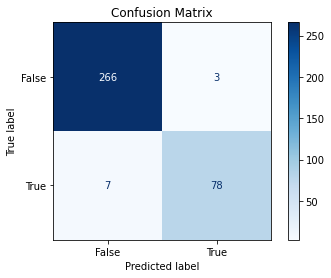

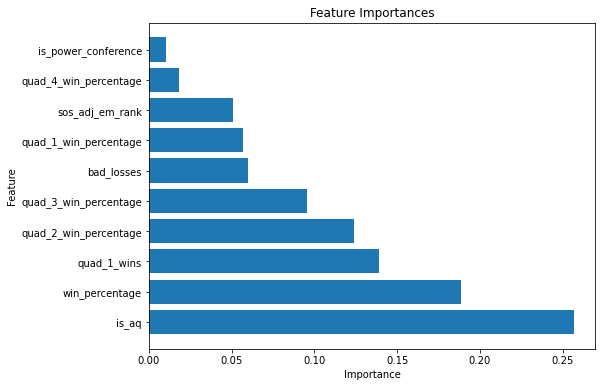

In [15]:
## random forest

features = ['sos_adj_em_rank', 'win_percentage', 'quad_1_win_percentage','quad_2_win_percentage',
            'quad_3_win_percentage', 'quad_4_win_percentage', 'is_aq', 'is_power_conference',
            'quad_1_wins', 'bad_losses']

X, y = merged[features], merged['made_tournament']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=68)

# train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=68)
clf.fit(X_train, y_train)

# make predictions on test set
y_pred = clf.predict(X_test)

# evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:\n', classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = sorted(set(merged['made_tournament'])))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# feature importance visualization
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(8, 6))
plt.title("Feature Importances")
plt.barh(range(X.shape[1]), importances[indices], align='center')
plt.yticks(range(X.shape[1]), feature_names[indices])
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()


The model ends up being pretty damn good at 97% accuracy. I'm not super surprised by this, most teams are going to be very easy to classify. We're more interested in classifying the bubble teams correctly, where you could reasonably argue each side. The above text explains why we can't use the model's prediction at surface level. So here, we predict the probability a team made the tournament from the model and take the top 68 per year, indicating the final prediction. 

This has one main issue. Random forests aren't predicting true probability. They are simply quantifying how many decision trees predicted one way or another. So, for example, if a team truly had a 60% chance to make the tournament, it's very possible that more than 60% of decision trees would classify that team as a tournament team, and we'd end up with an inflated probability. I'll explain some better ways to do this in the future improvements section, but for now, lets see how the model does with this approach.

In [21]:
## take top 68 prob per year

probabilities = clf.predict_proba(X)[:, 1]

merged['tournament_prob'] = probabilities

merged['predicted_tournament'] = merged.groupby('year')['tournament_prob'].rank(method='first', ascending=False) <= 68

merged.head()

,team,year,conference,record,sos_adj_em_rank,adj_em,adj_em_rank,o_adj_rank,d_adj_rank,wins,...,quad_4_win_percentage,postseason_champion,seed,is_aq,made_tournament,is_power_conference,quad_1_wins,bad_losses,tournament_prob,predicted_tournament
0,Virginia,2019,ACC,29-3,22,34.22,1,2,5,29.0,...,1.0,NaN,1,False,True,True,12,0,1.0,True
1,Gonzaga,2019,WCC,30-3,75,32.85,2,1,12,30.0,...,1.0,NaN,1,False,True,False,4,0,1.0,True
2,Michigan St.,2019,B10,28-6,2,30.81,3,5,9,28.0,...,1.0,Michigan St.,2,True,True,True,13,0,1.0,True
3,Duke,2019,ACC,29-5,7,30.62,4,7,6,29.0,...,1.0,Duke,1,True,True,True,11,0,1.0,True
4,Texas Tech,2019,B12,26-6,21,30.03,5,25,1,26.0,...,1.0,NaN,3,False,True,True,8,1,1.0,True


Taking the top 68 per year, we end up with 3 missed predictions, which means two perfect years in 2021 and 2024. I'll take that!

In [22]:
## predicted to make but missed
merged[(merged['predicted_tournament']) & (~merged['made_tournament'])][['team', 'year', 'conference', 'record']]

,team,year,conference,record
86,UNC Greensboro,2019,SC,28-6
732,Texas A&M,2022,SEC,22-12
1125,Clemson,2023,ACC,23-10


And for each team we predicted to make but missed, there's also a team we predicted to make but missed.

Some thoughts on why:

**2019 - model predicts UNC Greensboro over Syracuse**

Syracuse ended up as an 8 seed, and I'm honestly not sure how. They had some bad home losses to Old Dominion and Georgia Tech. They did have an elite road win against Duke, and the ACC was very strong this year. So, they definitely have an argument to make the tournament, and predictive metrics / brand name could have pushed them up to an 8 seed. This also brings up a flaw in my current model and the quad system in general. Stuffing everything in a quad record has no way to differentiate that Syracuse's road win over Duke, an eventual 1 seed, is basically the best win you can possibly have. Quad 1 puts that in the same group as a home win over the #30 team in the country. 

UNC Greensboro ended up as a 1 seed in the NIT, so it looks like we were close at least. My guess is the model saw a ton of wins and two quad 1 wins (not knowing they were weak quad 1) and made the wrong prediction. 

**2022 - model predicts Texas A&M over Rutgers** 

Unlike Syracuse, this was right on the bubble with Syracuse Last Four In and Texas A&M as an NIT one seed. Nothing significant stands out here, except that Texas A&M went on a deep SEC tourney run, so it's probably worth breaking those out somehow, since conference tourney wins tend to not be as significant in the committee's eyes. 

**2023 - model predicts Clemson over NC State**

Nothing new sticking out here either. Looks like Clemson had some pretty bad losses, which NC State did not, which probably pushed the Wolfpack in. I would hope the `bad_losses` would have helped with that, but it won't be perfect.

In [23]:
## predicted to miss but made
merged[(~merged['predicted_tournament']) & (merged['made_tournament'])][['team', 'year', 'conference', 'record']]

,team,year,conference,record
38,Syracuse,2019,ACC,20-13
776,Rutgers,2022,B10,18-13
1109,N.C. State,2023,ACC,23-10


## Drawbacks and Future Work

The biggest issue here is that the inputs should be scaled per year. This would combat the problem of the model viewing teams agnostic of year. This would also create a nice side effect - you could then use it to predict the tournament teams at any point in the season instead of relying on a completed season's resumes. 

Also, some sort of logistic model would probably work better (or at least be more interpretable). The need to take the top 68 teams and not just use the model's classification recquires some representation of probability, which a Random Forest is not great at. 

There are more features I could use as well. The quad system is clunky and doesn't do well at identifying subtle differences within quads. This year, the committee is utilizing Wins Above Bubble (WAB) which should be a much better representation of a team's resume in my opinion. So I would like to figure out a way to apply that historically and use in prediction. 

Outside of the model, I would like to set up season simulations you could use to quanitfy the chance a team makes a tournament at any point. For example, you could simulate 1000 seasons for a team and then use the classifier to check how many times they ended up doing enough to make the tournament. 

One last drawback - while this does do pretty well on our test set, the way we are evaluating the final results may be due artifically improved by some overfitting. Since we are basically testing on teams the model trained on, it's hard to completely trust the "only 3 incorrect prediction" part. So, the next section takes the resume's of the 2025 season and makes a prediction on this year's tournament field.

## 2025 Prediction

In [16]:
kenpom_ratings = []

## loop through kenpom data 
ratings = get_pomeroy_ratings(browser, 2025)
ratings['year'] = 2025
kenpom_ratings.append(ratings) 

kenpom_ratings = pd.concat(kenpom_ratings, ignore_index=True)

## remove 2020, no tournament
kenpom_ratings = kenpom_ratings[kenpom_ratings['year'] != 2020]

## select columns of interest
kenpom_ratings = kenpom_ratings[['Team', 'year', 'Seed', 'Conf', 'W-L', 'SOS-AdjEM.Rank', 'AdjEM', 'AdjO.Rank', 'AdjD.Rank']]

## rename columns
kenpom_ratings.columns = ['team', 'year', 'seed', 'conference', 'record', 'sos_adj_em_rank', 'adj_em', 'o_adj_rank', 'd_adj_rank']

## convert wins and losses to percentage
kenpom_ratings[['wins', 'losses']] = kenpom_ratings['record'].str.split('-', expand=True).astype(int)

## remove teams who didn't play a 2021 season
kenpom_ratings = kenpom_ratings[kenpom_ratings['wins'] + kenpom_ratings['losses'] > 0]

## drop wins and losses, kenpom tracks from after tournament
kenpom_ratings = kenpom_ratings.drop(['wins', 'losses'], axis = 1)

## remove '+' from adjusted efficiency, convert to double
kenpom_ratings['adj_em'] = kenpom_ratings['adj_em'].str.replace('+', '', regex=False).astype('double')

## create rank column for efficiency
kenpom_ratings['adj_em_rank'] = kenpom_ratings.groupby('year')['adj_em'].rank(ascending=False, method='min').astype(int)

kenpom_ratings.head()

,team,year,seed,conference,record,sos_adj_em_rank,adj_em,o_adj_rank,d_adj_rank,adj_em_rank
0,Duke,2025,1,ACC,31-3,56,38.16,3,4,1
1,Florida,2025,1,SEC,30-4,17,36.16,1,10,2
2,Houston,2025,1,B12,30-4,24,35.44,10,2,3
3,Auburn,2025,1,SEC,28-5,2,35.05,2,12,4
4,Tennessee,2025,2,SEC,27-7,6,31.15,18,3,5


In [18]:
import pandas as pd

# Data as a list of tuples
data = [
    (2025, "SEC", "Florida"),
    (2025, "WCC", "Gonzaga"),
    (2025, "B12", "Houston"),
    (2025, "B10", "Michigan"),
    (2025, "BE", "St. John's"),
    (2025, "Amer", "Memphis"),
    (2025, "MAC", "Akron"),
    (2025, "MVC", "Drake"),
    (2025, "A10", "VCU"),
    (2025, "SC", "Wofford"),
    (2025, "ACC", "Duke"),
    (2025, "Horz", "Robert Morris"),
    (2025, "BW", "UC San Diego"),
    (2025, "SB", "Troy"),
    (2025, "NEC", "Saint Francis"),
    (2025, "Ivy", "Yale"),
    (2025, "CAA", "UNC Wilmington"),
    (2025, "WAC", "Grand Canyon"),
    (2025, "CUSA", "Liberty"),
    (2025, "OVC", "SIUE"),
    (2025, "PL", "American"),
    (2025, "MWC", "Colorado St."),
    (2025, "Slnd", "McNeese"),
    (2025, "BSky", "Montana"),
    (2025, "ASun", "Lipscomb"),
    (2025, "AE", "Bryant"),
    (2025, "Sum", "Nebraska Omaha"),
    (2025, "BSth", "High Point"),
    (2025, "MAAC", "Mount St. Mary's"),
    (2025, "SWAC", "Alabama St."),
    (2025, "MEAC", "Norfolk St."),
]

# Create DataFrame
champs25 = pd.DataFrame(data, columns=["year", "conference", "postseason_champion"])

# Display DataFrame
champs25.head()

,year,conference,postseason_champion
0,2025,SEC,Florida
1,2025,WCC,Gonzaga
2,2025,B12,Houston
3,2025,B10,Michigan
4,2025,BE,St. John's


In [19]:
## loop through HTML from bracketologists.com to get historical quad record data

quad_records_data = []

for date in ['2025-03-15']:
    quad_records = scrape_quad_records(date)
    quad_records_data = [*quad_records_data, *quad_records]

## create pandas df for quad records
quad_records = pd.DataFrame(quad_records_data)

## replace 'State' with 'St.'
quad_records['team'] = quad_records['team'].str.replace('State', 'St.')

## remove '-'
quad_records['team'] = quad_records['team'].str.replace('-', ' ')

## manual team name mapping to kenpom data
quad_records_team_name_mapping = {
 'CSUN': 'Cal St. Northridge',
 'California Baptist': 'Cal Baptist',
 'Central Connecticut St.': 'Central Connecticut',
 'East Texas A&M': 'Texas A&M Commerce',
 'Florida International': 'FIU',
 "Hawai'i": 'Hawaii',
 'IU Indy': 'IUPUI',
 'Kansas City': 'UMKC',
 'Loyola (MD)': 'Loyola MD',
 'McNeese St.': 'McNeese',
 'MD Eastern Shore': 'Maryland Eastern Shore',
 'Miami (FL)': 'Miami FL',
 'Miami (OH)': 'Miami OH',
 'NC St.': 'N.C. State',
 'Ole Miss': 'Mississippi',
 'Omaha': 'Nebraska Omaha',
 'Pennsylvania': 'Penn',
 'SE Missouri St.': 'Southeast Missouri St.',
 'Saint Francis (BKN)': 'Saint Francis',
 'Sam Houston': 'Sam Houston St.',
 'SIU Edwardsville': 'SIUE',
 'South Carolina Upstate': 'USC Upstate',
 "St. Peter's": "Saint Peter's",
 'Texas A&M CC': 'Texas A&M Corpus Chris',
 'UAlbany': 'Albany',
 'UConn': 'Connecticut',
 'UIC': 'Illinois Chicago',
 'UT Martin': 'Tennessee Martin'
}

quad_records['team'] = quad_records['team'].map(quad_records_team_name_mapping).fillna(quad_records['team'])

## create wins and losses column
quad_records[['wins', 'losses']] = quad_records['record'].str.split('-', expand=True).astype(int)

## create win percentage columns
quad_records['win_percentage'] = quad_records['wins'] / (quad_records['wins'] + quad_records['losses'])
    
quad_records.head()

,team,year,record,quad_1_record,quad_2_record,quad_3_record,quad_4_record,non_d1_record,wins,losses,win_percentage
0,Duke,2025,31-3,9-3,7-0,10-0,5-0,0-0,31,3,0.911765
1,Auburn,2025,28-5,16-5,6-0,2-0,4-0,0-0,28,5,0.848485
2,Houston,2025,30-4,14-3,6-1,5-0,5-0,0-0,30,4,0.882353
3,Florida,2025,29-4,10-4,9-0,4-0,6-0,0-0,29,4,0.878788
4,Tennessee,2025,27-6,11-6,5-0,5-0,6-0,0-0,27,6,0.818182


In [20]:
## calculate each quad win percentage

## helper function to apply to each column
def calculate_win_percentage(record):
    wins, losses = map(int, record.split('-'))
    total_games = wins + losses
    return 0 if total_games == 0 else wins / total_games

for i in range(1, 5):
    quad_records[f'quad_{i}_win_percentage'] = quad_records[f'quad_{i}_record'].apply(calculate_win_percentage)
    
quad_records.head()


,team,year,record,quad_1_record,quad_2_record,quad_3_record,quad_4_record,non_d1_record,wins,losses,win_percentage,quad_1_win_percentage,quad_2_win_percentage,quad_3_win_percentage,quad_4_win_percentage
0,Duke,2025,31-3,9-3,7-0,10-0,5-0,0-0,31,3,0.911765,0.750000,1.000000,1.0,1.0
1,Auburn,2025,28-5,16-5,6-0,2-0,4-0,0-0,28,5,0.848485,0.761905,1.000000,1.0,1.0
2,Houston,2025,30-4,14-3,6-1,5-0,5-0,0-0,30,4,0.882353,0.823529,0.857143,1.0,1.0
3,Florida,2025,29-4,10-4,9-0,4-0,6-0,0-0,29,4,0.878788,0.714286,1.000000,1.0,1.0
4,Tennessee,2025,27-6,11-6,5-0,5-0,6-0,0-0,27,6,0.818182,0.647059,1.000000,1.0,1.0


In [22]:
## combine data sets

## kenpom to quad records
merged25 = pd.merge(kenpom_ratings, quad_records, left_on = ['team', 'year'], right_on = ['team', 'year'], how = 'left')

## to automatic qualifiers
merged25 = pd.merge(merged25, champs25, left_on = ['team', 'year'], right_on = ['postseason_champion', 'year'], how = 'left')

## to tournament teams
merged25 = pd.merge(merged25, tournament_teams, left_on = ['team', 'year'], right_on = ['team', 'year'], how = 'left')

## select cols
cols = ['team', 'year', 'conference_x', 'record_y',
       'sos_adj_em_rank', 'adj_em', 'adj_em_rank', 'o_adj_rank', 'd_adj_rank', 'wins',
       'losses', 'win_percentage', 'quad_1_record',
       'quad_2_record', 'quad_3_record', 'quad_4_record', 'non_d1_record',
       'quad_1_win_percentage', 'quad_2_win_percentage',
       'quad_3_win_percentage', 'quad_4_win_percentage',
       'postseason_champion', 'seed_y']

merged25 = merged25[cols]

## rename cols
merged25.columns = ['team', 'year', 'conference', 'record',
       'sos_adj_em_rank', 'adj_em', 'adj_em_rank', 'o_adj_rank', 'd_adj_rank', 'wins',
       'losses', 'win_percentage', 'quad_1_record',
       'quad_2_record', 'quad_3_record', 'quad_4_record', 'non_d1_record',
       'quad_1_win_percentage', 'quad_2_win_percentage',
       'quad_3_win_percentage', 'quad_4_win_percentage',
       'postseason_champion', 'seed']

## is automatic qualifier feature
merged25['is_aq'] = merged25['postseason_champion'].notna()

## made tournament column (i.e. what we are predicting)
merged25['made_tournament'] = merged25['seed'].notna()

## is power conference feature
power_conferences = ['ACC', 'B10', 'B12', 'SEC', 'P12', 'BE']

merged25['is_power_conference'] = merged25['conference'].isin(power_conferences)

## filter out teams who did not play
merged25 = merged25[merged25['quad_1_record'].notnull()]

## total quad 1 wins feature
merged25['quad_1_wins'] = merged25['quad_1_record'].str.split('-', expand=True).astype(int)[0]

## bad losses feature - quad 3 + quad 4 losses
merged25['bad_losses'] = merged25['quad_3_record'].str.split('-', expand=True).astype(int)[1] + merged25['quad_4_record'].str.split('-', expand=True).astype(int)[1]

merged25.head()

,team,year,conference,record,sos_adj_em_rank,adj_em,adj_em_rank,o_adj_rank,d_adj_rank,wins,...,quad_2_win_percentage,quad_3_win_percentage,quad_4_win_percentage,postseason_champion,seed,is_aq,made_tournament,is_power_conference,quad_1_wins,bad_losses
0,Duke,2025,ACC,31-3,56,38.16,1,3,4,31.0,...,1.000000,1.0,1.0,Duke,NaN,True,False,True,9,0
1,Florida,2025,SEC,29-4,17,36.16,2,1,10,29.0,...,1.000000,1.0,1.0,Florida,NaN,True,False,True,10,0
2,Houston,2025,B12,30-4,24,35.44,3,10,2,30.0,...,0.857143,1.0,1.0,Houston,NaN,True,False,True,14,0
3,Auburn,2025,SEC,28-5,2,35.05,4,2,12,28.0,...,1.000000,1.0,1.0,NaN,NaN,False,False,True,16,0
4,Tennessee,2025,SEC,27-6,6,31.15,5,18,3,27.0,...,1.000000,1.0,1.0,NaN,NaN,False,False,True,11,0


In [23]:
features = ['sos_adj_em_rank', 'win_percentage', 'quad_1_win_percentage','quad_2_win_percentage',
            'quad_3_win_percentage', 'quad_4_win_percentage', 'is_aq', 'is_power_conference',
            'quad_1_wins', 'bad_losses']

X = merged25[features]

# make predictions on test set
y_pred = clf.predict(X)

y_pred

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True, False, False,
        True, False, False,  True,  True,  True,  True,  True, False,
       False, False, False,  True,  True, False, False,  True, False,
       False, False, False, False, False, False, False,  True, False,
        True, False, False, False, False, False, False, False, False,
       False,  True,  True, False, False, False, False, False, False,
       False, False,  True, False, False, False, False,  True,  True,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False,

In [24]:
probabilities = clf.predict_proba(X)[:, 1]

merged25['tournament_prob'] = probabilities

merged25['predicted_tournament'] = merged25.groupby('year')['tournament_prob'].rank(method='first', ascending=False) <= 68

merged.head()

,team,year,conference,record,sos_adj_em_rank,adj_em,adj_em_rank,o_adj_rank,d_adj_rank,wins,...,quad_2_win_percentage,quad_3_win_percentage,quad_4_win_percentage,postseason_champion,seed,is_aq,made_tournament,is_power_conference,quad_1_wins,bad_losses
0,Virginia,2019,ACC,29-3,22,34.22,1,2,5,29.0,...,1.000000,1.00,1.0,NaN,1,False,True,True,12,0
1,Gonzaga,2019,WCC,30-3,75,32.85,2,1,12,30.0,...,1.000000,1.00,1.0,NaN,1,False,True,False,4,0
2,Michigan St.,2019,B10,28-6,2,30.81,3,5,9,28.0,...,0.750000,1.00,1.0,Michigan St.,2,True,True,True,13,0
3,Duke,2019,ACC,29-5,7,30.62,4,7,6,29.0,...,0.857143,1.00,1.0,Duke,1,True,True,True,11,0
4,Texas Tech,2019,B12,26-6,21,30.03,5,25,1,26.0,...,1.000000,0.75,1.0,NaN,3,False,True,True,8,1


In [26]:
pd.set_option('display.max_rows', 68)

merged25[merged25['predicted_tournament']][['team', 'record', 'conference', 'tournament_prob']].sort_values(['team'])

,team,record,conference,tournament_prob
98,Akron,26-6,MAC,0.98
5,Alabama,25-8,SEC,1.00
272,Alabama St.,18-15,SWAC,0.90
236,American,20-12,PL,0.94
13,Arizona,22-12,B12,1.00
39,Arkansas,20-13,SEC,0.79
3,Auburn,28-5,SEC,1.00
23,BYU,24-9,B12,1.00
28,Baylor,18-14,B12,0.58
49,Boise St.,23-10,MWC,0.77


in but maybe not

North Carolina
Boise St.

out but maybe not

Indiana
West Virginia

In [165]:
merged[merged['predicted_tournament']]['team'].to_csv('made_teams.csv')

In [30]:
bubble_teams = ['West Virginia', 'Indiana', 'Xavier', 'North Carolina', 'Texas', 'Boise St.']

merged25[merged25['team'].isin(bubble_teams)][['team', 'conference', 'record'] + features]

,team,conference,record,sos_adj_em_rank,win_percentage,quad_1_win_percentage,quad_2_win_percentage,quad_3_win_percentage,quad_4_win_percentage,is_aq,is_power_conference,quad_1_wins,bad_losses
32,North Carolina,ACC,22-13,41,0.628571,0.076923,1.000000,0.875000,1.000000,False,True,1,1
42,Xavier,BE,21-11,59,0.656250,0.100000,0.800000,1.000000,1.000000,False,True,1,0
43,Texas,SEC,19-15,20,0.558824,0.411765,0.375000,1.000000,1.000000,False,True,7,0
47,Indiana,B10,19-13,28,0.593750,0.235294,1.000000,1.000000,1.000000,False,True,4,0
49,Boise St.,MWC,23-10,78,0.696970,0.333333,0.714286,0.833333,0.909091,False,False,3,2
52,West Virginia,B12,19-13,30,0.593750,0.375000,0.571429,1.000000,1.000000,False,True,6,0
